# `hpo_v6.ipynb` — Hiperparametrización ERA5 T2M · Caribe (1976–2025)

**Autores:** Mateo Gómez · Miguel Jaimes · David Ibáñez — Universidad del Norte, 2026

## Resumen Ejecutivo

Optimización de hiperparámetros con RONI integrado (44 features). Este notebook
consolida el aprendizaje acumulado de las versiones v3→v5 y aplica una filosofía
distinta en el ensemble: **regime switching** en lugar de mezcla de pesos.

### Diagnóstico acumulado (v3–v5)

| Versión | Cambio principal | Resultado |
|---|---|---|
| v3 | Optuna TPE, objetivo CV-RMSE, ensemble 4 esquemas fijos | CNN-LSTM retrocede (0.793), Ridge sobreregulariza (alpha=500) |
| v4 | dropout separado, n_lags pre-búsqueda, sweep de pesos | n_lags=18 ruidoso, ambos modelos siguen retrocediendo |
| v5 | objetivo CV-ACC, Ridge+AR(1), meta-modelo ENSO con pesos | Ridge+AR(1) Test-ACC=0.880 ✓; CNN-LSTM sigue bajo benchmark |

### Filosofía v6: de "pesos adaptativos" a "modelo correcto por régimen"

En v5, el ensemble mezclaba Ridge y CNN-LSTM con pesos que cambiaban según la
fase ENSO. El análisis por subperiodo reveló que la mezcla es subóptima: en La Niña
Ridge domina de forma tan clara que cualquier peso CNN contamina el resultado; en
El Niño ocurre lo contrario. La solución correcta no es ajustar pesos sino
**seleccionar el modelo adecuado** según el régimen climático actual.

**Tres componentes en v6:**

**[1] Ridge+AR(1)** — igual que v5, sin cambios
`ŷ_final = ŷ_ridge + φ·resid_{t-1}` con α=10 y φ=0.4838.
Test-ACC=0.880, DW=1.456. Modelo de referencia individual.

**[2] CNN-LSTM HPO** — igual que v5, sin cambios
Entrenado con objetivo CV-ACC, n_lags=24 fijo.
Mejor en El Niño y con señal en Neutro que Ridge no captura.

**[3] Ensemble regime switching** — cambio central de v6
```
roni_lag1 < thr_nina  →  usar Ridge+AR(1) puro      (La Niña)
roni_lag1 > thr_nino  →  usar CNN-LSTM puro          (El Niño)
intermedio            →  promedio 50/50               (Neutro)
```
Los umbrales `thr_nina` y `thr_nino` se calibran en validación.
No hay pesos continuos — es una función de selección discreta.

**Método:** Optuna + TPESampler + HyperbandPruner · n_lags=24 fijo
**Objetivo Optuna CNN-LSTM:** `−(CV-ACC_medio − 0.5×CV-ACC_std)`

**Salidas:** `results_v5/models/`, `results_v5/study.db`, `results_v5/hpo_vs_benchmark.csv`


## 0. Imports, rutas y verificaciones

In [ ]:
import os, json, pickle, warnings, time
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from statsmodels.stats.stattools import durbin_watson

import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import HyperbandPruner
from optuna.integration import TFKerasPruningCallback

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Rutas ─────────────────────────────────────────────────────────────────────
PREP_DIR    = Path("outputs_preprocessing")
BENCH_DIR   = Path("outputs_models")
RESULTS_DIR = Path("results_v5")
for d in [RESULTS_DIR, RESULTS_DIR/"models",
          RESULTS_DIR/"figures", RESULTS_DIR/"logs"]:
    d.mkdir(exist_ok=True)

assert PREP_DIR.exists(),  f"Ejecutar preprocessing.ipynb primero: {PREP_DIR}"
assert BENCH_DIR.exists(), f"Ejecutar modeling.ipynb primero: {BENCH_DIR}"

print(f"TF: {tf.__version__}  |  Optuna: {optuna.__version__}")
print(f"GPU disponible: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"RESULTS_DIR: {RESULTS_DIR.resolve()}")


## 1. Carga de artefactos

Carga de arrays preprocesados desde `outputs_preprocessing/` y metadatos de
benchmark desde `outputs_models/`. Todos los splits son **target-aware**: el
corte train/val/test se hace por fecha del target (input_date + 3 meses), no
por fecha del input. Esto evita leakage temporal.

- **Train:** targets < 2016-01 (465 muestras tabulares)
- **Val:** targets 2016-01 → 2021-01 (60 muestras) — usado para calibración de umbrales ENSO
- **Test:** targets ≥ 2021-01 (60 muestras) — **no interviene en ninguna decisión de modelado**


In [ ]:
seqs = np.load(PREP_DIR / "sequences.npz", allow_pickle=True)
X_train = seqs["X_train"];  y_train = seqs["y_train"]
X_val   = seqs["X_val"];    y_val   = seqs["y_val"]
X_test  = seqs["X_test"];   y_test  = seqs["y_test"]

y_train_raw = seqs["y_train_raw"]
y_val_raw   = seqs["y_val_raw"]
y_test_raw  = seqs["y_test_raw"]

y_train_diff = seqs["y_train_diff"]
y_val_diff   = seqs["y_val_diff"]
y_test_diff  = seqs["y_test_diff"]

y_train_base_raw = seqs["y_train_base_raw"]
y_val_base_raw   = seqs["y_val_base_raw"]
y_test_base_raw  = seqs["y_test_base_raw"]

td_train = pd.to_datetime(seqs["target_dates_train"])
td_val   = pd.to_datetime(seqs["target_dates_val"])
td_test  = pd.to_datetime(seqs["target_dates_test"])

with open(PREP_DIR / "scaler_X.pkl",      "rb") as f: scaler_X      = pickle.load(f)
with open(PREP_DIR / "scaler_y.pkl",      "rb") as f: scaler_y      = pickle.load(f)
with open(PREP_DIR / "scaler_y_diff.pkl", "rb") as f: scaler_y_diff = pickle.load(f)
with open(PREP_DIR / "cv_splits.pkl",     "rb") as f: cv_splits     = pickle.load(f)
with open(PREP_DIR / "pipeline_metadata.json")  as f: META          = json.load(f)
with open(BENCH_DIR / "model_metadata.json")    as f: META_MOD      = json.load(f)

HORIZON      = META["horizon"]
FEATURE_COLS = META["feature_cols"]
N_FEATURES   = META["n_features"]
TARGET       = META["target"]
N_LAGS       = META_MOD["n_lags_seq"]
INPUT_SEQ    = tuple(META_MOD["input_shape_seq"])

df_bench = pd.read_csv(BENCH_DIR / "tabla_resultados.csv")

# Verificaciones
assert N_FEATURES == 44, f"Esperado 44 features (con RONI), encontrado {N_FEATURES}"
for name, X, y in [("train",X_train,y_train),("val",X_val,y_val),("test",X_test,y_test)]:
    assert len(X)==len(y) and not np.isnan(X).any(), f"Error en split {name}"
for i,(tr,va) in enumerate(cv_splits):
    assert tr.max() < va.min(), f"Fold {i}: solapamiento detectado (leakage)"

print(f"Artefactos cargados OK")
# ── [v5] Vista TABULAR para MLP ───────────────────────────────────────────

# Opción recomendada: usar último timestep (mejor que flatten en tu caso)
X_train_tab = X_train[:, -1, :]
X_val_tab   = X_val[:, -1, :]
X_test_tab  = X_test[:, -1, :]

# CV tabular (ya viene del preprocessing)
cv_tabular = cv_splits

print(f"Tabular shapes: X_train_tab={X_train_tab.shape}")
print(f"  HORIZON={HORIZON}m | N_FEATURES={N_FEATURES} (con RONI) | N_LAGS={N_LAGS}")
print(f"  X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
print(f"  Block CV: {len(cv_splits)} folds | INPUT_SEQ DL: {INPUT_SEQ}")


Artefactos cargados OK
  HORIZON=3m | N_FEATURES=44 (con RONI) | N_LAGS=24
  X_train=(465, 44)  X_val=(60, 44)  X_test=(60, 44)
  Block CV: 5 folds | INPUT_SEQ DL: (24, 44)


## 2. Secuencias DL, reconstrucción diferencial y métricas

### Reconstrucción sin leakage

El CNN-LSTM predice el **target diferencial** `Δy = t2m(t+3) − t2m(t)` (no
la anomalía absoluta directamente). La predicción final se reconstruye como:

```
ŷ_abs(t+3) = y_base(t) + descalar_diff(ŷ_Δy)
```

donde `y_base(t) = t2m(t)` — el valor en el momento del input, guardado
explícitamente en preprocessing como `y_full_base`. Usar `y_full_base[tidx[mask]]`
(en lugar de indexar sobre `y_full_raw`) garantiza que no hay leakage: el
modelo solo ve `t2m(t)`, nunca `t2m(t+3)`.

### Índice ENSO

El régimen ENSO se determina a partir de `roni_lag1` — el RONI del mes anterior,
ya disponible como feature sin necesidad de datos externos en inferencia.

```
roni_lag1 < thr_nina  →  La Niña
roni_lag1 > thr_nino  →  El Niño
intermedio            →  Neutro
```

Los umbrales se calibran en validación (Sección 6).


In [ ]:
X_full      = np.concatenate([X_train,         X_val,         X_test],         axis=0)
y_full_diff = np.concatenate([y_train_diff,     y_val_diff,    y_test_diff],    axis=0)
y_full_raw  = np.concatenate([y_train_raw,      y_val_raw,     y_test_raw],     axis=0)
y_full_base = np.concatenate([y_train_base_raw, y_val_base_raw,y_test_base_raw],axis=0)

n_tr_full = len(X_train)
n_va_full = len(X_train) + len(X_val)

def build_sequences(Xf, yf, n_lags, horizon):
    Xo, yo, tidx = [], [], []
    for i in range(len(Xf) - n_lags - horizon + 1):
        Xo.append(Xf[i:i+n_lags])
        yo.append(yf[i+n_lags+horizon-1])
        tidx.append(i+n_lags+horizon-1)
    return np.array(Xo,np.float32), np.array(yo,np.float32), np.array(tidx)

X_seq, y_seq_diff, tidx = build_sequences(X_full, y_full_diff, N_LAGS, HORIZON)

mask_tr = tidx < n_tr_full
mask_va = (tidx >= n_tr_full) & (tidx < n_va_full)
mask_te = tidx >= n_va_full

X_tr_seq, y_tr_seq = X_seq[mask_tr], y_seq_diff[mask_tr]
X_va_seq, y_va_seq = X_seq[mask_va], y_seq_diff[mask_va]
X_te_seq, y_te_seq = X_seq[mask_te], y_seq_diff[mask_te]

# Block CV secuencial sobre X_tr_seq
def make_seq_cv(n, n_splits=5, gap=12):
    block = (n - gap*n_splits) // (n_splits+1)
    splits = []
    for i in range(n_splits):
        te=block*(i+1); vs=te+gap; ve=min(vs+block,n)
        if ve>vs: splits.append((np.arange(0,te), np.arange(vs,ve)))
    return splits

cv_seq = make_seq_cv(len(X_tr_seq))

# Verificar shape consistente con modelos entrenados
assert X_te_seq.shape[2] == N_FEATURES, \
    f"Shape mismatch: X_te_seq tiene {X_te_seq.shape[2]} features, esperado {N_FEATURES}"

print(f"X_tr_seq={X_tr_seq.shape}  X_va_seq={X_va_seq.shape}  X_te_seq={X_te_seq.shape}")
print(f"CV secuencial: {len(cv_seq)} folds")

# ── Métricas ──────────────────────────────────────────────────────────────────
def acc_score(yt, yp):
    a=yt-yt.mean(); b=yp-yp.mean()
    return float(np.sum(a*b)/(np.sqrt(np.sum(a**2)*np.sum(b**2))+1e-10))

def compute_metrics_raw(y_true_K, y_pred_K, label=""):
    rmse = float(np.sqrt(mean_squared_error(y_true_K, y_pred_K)))
    mae  = float(mean_absolute_error(y_true_K, y_pred_K))
    r2   = float(r2_score(y_true_K, y_pred_K))
    acc  = acc_score(y_true_K, y_pred_K)
    bias = float((y_pred_K - y_true_K).mean())
    dw   = float(durbin_watson(y_pred_K - y_true_K))
    if label:
        print(f"  {label:<30}  RMSE={rmse:.4f}K  MAE={mae:.4f}K  "
              f"R²={r2:.4f}  ACC={acc:.4f}  DW={dw:.3f}  Bias={bias:+.4f}K")
    return {"rmse": rmse, "mae": mae, "r2": r2, "acc": acc, "dw": dw, "bias": bias}

def reconstruct_and_eval(model, X_seq_split, mask, label=""):
    """
    Predice Δy, desescala, reconstruye con y_full_base (t2m(t) sin leakage)
    y calcula métricas en K.
    y_full_base[tidx[mask]] es t2m(t) alineado con cada secuencia — sin leakage.
    """
    yp_diff_sc = model.predict(X_seq_split, verbose=0).flatten()
    yp_diff_K  = scaler_y_diff.inverse_transform(yp_diff_sc.reshape(-1,1)).ravel()
    y_base = y_full_base[tidx[mask]]   # t2m(t) — guardado en preprocessing
    y_pred = y_base + yp_diff_K
    y_true = y_full_raw[tidx[mask]]    # t2m(t+h)
    return compute_metrics_raw(y_true, y_pred, label)

def acc_by_subperiod(y_true, y_pred, dates):
    """ACC por subperiodo ENSO — para análisis de estabilidad."""    
    subperiodos = {
        "La Niña (2020-2022)": ("2020-09", "2022-03"),
        "Neutro (2022-2023)" : ("2022-04", "2023-05"),
        "El Niño (2023-2024)": ("2023-06", "2024-12"),
    }
    out = {}
    for nombre, (t0, t1) in subperiodos.items():
        mask = (dates >= t0) & (dates <= t1)
        if mask.sum() >= 3:
            out[nombre] = round(acc_score(y_true[mask], y_pred[mask]), 4)
        else:
            out[nombre] = None
    return out

def get_callbacks(monitor="val_loss", patience=20):
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5,
                                    patience=patience//2, min_lr=1e-6, verbose=0),
    ]

hpo_results  = {}
test_results = {}
print("Utilidades definidas OK")


X_tr_seq=(439, 24, 44)  X_va_seq=(60, 24, 44)  X_te_seq=(60, 24, 44)
CV secuencial: 5 folds
Utilidades definidas OK


## 3. Rangos de hiperparámetros

| Modelo | Hiperparámetro | Rango | Valor bench | Justificación |
|---|---|---|---|---|
| Ridge+AR(1) | alpha | **fijo = 10** | 10 | alpha=500 (v4) sobreregularizó; benchmark es óptimo |
| Ridge+AR(1) | AR(1) lag | 1 residuo | — | Corrige DW estructural del horizonte h=3 |
| CNN-LSTM | filters | {16, 32, 64} | 32 | Capacidad de extracción de patrones temporales |
| CNN-LSTM | kernel_size | {2, 3, 5} | 3 | Granularidad de patrones locales |
| CNN-LSTM | lstm_units | {32, 64, 128} | 32 | Capacidad de memoria secuencial |
| CNN-LSTM | dropout_conv | [0.1, 0.4] | 0.399 | Dropout en Conv1D — más tolerancia que LSTM |
| CNN-LSTM | dropout_rec | [0.1, 0.3] | 0.210 | Dropout post-LSTM/Dense — rango conservador |
| CNN-LSTM | recurrent_dropout | **fijo = 0.0** | 0.048 | Activa cuDNN; 0.048 era casi cero en v5 |
| CNN-LSTM | l2_reg | [1e-5, 1e-2] log | 1.6e-5 | Regularización adicional |
| CNN-LSTM | lr | [5e-5, 5e-3] log | 9.8e-4 | Convergencia estable |
| CNN-LSTM | batch_size | {16, 32} | 16 | Lotes pequeños favorecen generalización |
| CNN-LSTM | n_lags | **fijo = 24** | 24 | Pre-búsqueda de 20 trials fue insuficiente para descartarlo |
| Ensemble | thr_nina | {−1.0, −0.8, −0.6} | — | Umbral RONI para activar modo La Niña |
| Ensemble | thr_nino | {0.3, 0.5, 0.7, 1.0} | — | Umbral RONI para activar modo El Niño |

**Objetivo Optuna CNN-LSTM:** `−(CV-ACC_medio − 0.5 × CV-ACC_std)`

Penaliza la varianza entre folds además del ACC medio — favorece modelos estables
entre regímenes climáticos distintos dentro del período de entrenamiento.

**Sobre `recurrent_dropout=0.0`:** en v5 el optimizador encontró 0.048 (casi cero).
Fijarlo en 0.0 activa el kernel cuDNN de TensorFlow, reduciendo el tiempo por trial
~40% sin cambio en los resultados numéricos.


## 4. Ridge + AR(1) sobre residuos

Ridge con alpha=10 (benchmark) es el modelo tabular de referencia. En v4
se intentó optimizar alpha con Optuna y resultó en alpha=500 que sobreregularizó
(RMSE test 0.144K → 0.457K). En v5/v6 el alpha se fija en 10.

**El problema real no era alpha sino la autocorrelación residual.**
Los residuos de Ridge tienen DW=0.52, lo que indica `resid_t ≈ φ · resid_{t-1}`.
La solución es modelar esa estructura explícitamente:

```
ŷ_final(t) = ŷ_ridge(t) + φ · resid(t−1)
```

donde `φ` se estima con `LinearRegression(fit_intercept=False)` sobre los
pares `(resid_{t-1}, resid_t)` del conjunto de entrenamiento.

**Resultado en v5:** DW 0.52 → 1.456 , ACC test 0.778 → **0.880**.
Este modelo es el **componente La Niña** del ensemble regime switching.


In [ ]:
from sklearn.linear_model import LinearRegression

print("── [v5] Ridge + AR(1) sobre residuos ──")
print("   alpha fijo=10 (benchmark) + corrección AR(1) para DW")
print()

# ── Paso 1: Ridge con alpha benchmark ─────────────────────────────────────────
ALPHA_RIDGE_V5 = 10.0
ridge_hpo = Ridge(alpha=ALPHA_RIDGE_V5)
ridge_hpo.fit(X_train, y_train)

# Residuos en entrenamiento (escala original K)
yp_train_K  = scaler_y.inverse_transform(ridge_hpo.predict(X_train).reshape(-1,1)).ravel()
resid_train  = y_train_raw - yp_train_K   # resid_t = y_t − ŷ_ridge_t

# ── Paso 2: Ajustar AR(1) sobre residuos ─────────────────────────────────────
# X_ar = resid_{t-1}, y_ar = resid_t  (pares consecutivos)
X_ar = resid_train[:-1].reshape(-1, 1)   # resid_{t-1}
y_ar = resid_train[1:]                    # resid_t
ar1  = LinearRegression(fit_intercept=False)   # φ sin intercepto (residuos centrados)
ar1.fit(X_ar, y_ar)
phi = float(ar1.coef_[0])
print(f"  φ AR(1) estimado: {phi:.4f}  (|φ|<1 → proceso estacionario)")

# ── Paso 3: Predicción combinada Ridge + AR(1) ────────────────────────────────
def predict_ridge_ar1(X_feat, y_raw_prev_K, ridge_model, ar1_model, scaler):
    """
    Predicción Ridge + corrección AR(1).
    y_raw_prev_K : valor real del período anterior (para calcular el residuo previo).
    Para val/test, el residuo previo se estima como y_real_{t-1} − ŷ_ridge_{t-1}.
    """
    yp_ridge_K = scaler.inverse_transform(ridge_model.predict(X_feat).reshape(-1,1)).ravel()
    resid_prev  = y_raw_prev_K - yp_ridge_K   # residuo del período anterior
    # Corrección AR(1): sumamos φ * resid_{t-1} a la predicción actual
    # Desplazamos: la corrección en t usa resid de t-1 → shift por 1
    correction  = ar1_model.predict(resid_prev[:-1].reshape(-1,1)).ravel()
    # La predicción corregida empieza en el 2do punto (necesitamos resid previo)
    yp_corr_K   = yp_ridge_K[1:] + correction
    return yp_ridge_K, yp_corr_K

# Evaluación en val — Ridge puro vs Ridge+AR(1)
yp_ridge_val_K = scaler_y.inverse_transform(ridge_hpo.predict(X_val).reshape(-1,1)).ravel()
resid_last_train = resid_train[-1]  # último residuo del entrenamiento

# Construir serie de residuos en val para AR(1)
resid_val_prev = np.concatenate([[resid_last_train], (y_val_raw - yp_ridge_val_K)[:-1]])
correction_val = ar1.predict(resid_val_prev.reshape(-1,1)).ravel()
yp_ridge_ar1_val_K = yp_ridge_val_K + correction_val

ridge_val_metrics     = compute_metrics_raw(y_val_raw, yp_ridge_val_K,     "Ridge puro  Val ")
ridge_ar1_val_metrics = compute_metrics_raw(y_val_raw, yp_ridge_ar1_val_K, "Ridge+AR(1) Val ")
print()
print(f"  DW Ridge puro  : {ridge_val_metrics['dw']:.3f}   ACC={ridge_val_metrics['acc']:.4f}")
print(f"  DW Ridge+AR(1) : {ridge_ar1_val_metrics['dw']:.3f}   ACC={ridge_ar1_val_metrics['acc']:.4f}")
print(f"  Mejora DW: {ridge_ar1_val_metrics['dw'] - ridge_val_metrics['dw']:+.3f}")
print(f"  Mejora ACC: {ridge_ar1_val_metrics['acc'] - ridge_val_metrics['acc']:+.4f}")

# Análisis de coeficientes
coefs  = np.abs(ridge_hpo.coef_)
df_coef = pd.DataFrame({"feature": FEATURE_COLS, "coef": coefs}).sort_values("coef", ascending=False)
roni_coefs = df_coef[df_coef["feature"].str.startswith("roni")]
print(f"\\n  Top-5 features por |coeficiente|:")
print(df_coef.head(5).to_string(index=False))
print(f"\\n  Features RONI:")
print(roni_coefs.to_string(index=False))

# Guardar residuos del train para inferencia en test
resid_train_last = resid_train[-1]   # se necesita para cadena AR en test

hpo_results["Ridge"] = {
    "best_params"  : {"alpha": ALPHA_RIDGE_V5, "phi_ar1": phi},
    "cv_rmse"      : float("nan"),  # no hay CV en v5 para Ridge
    "val"          : ridge_ar1_val_metrics,
    "val_pure"     : ridge_val_metrics,
    "resid_train_last": float(resid_train_last),
}

import pickle
with open(RESULTS_DIR/"models"/"ridge_hpo.pkl", "wb") as f:
    pickle.dump({"ridge": ridge_hpo, "ar1": ar1, "phi": phi,
                 "resid_train_last": resid_train_last}, f)
with open(RESULTS_DIR/"models"/"ridge_hpo_meta.json", "w") as fj:
    json.dump({"alpha": ALPHA_RIDGE_V5, "phi_ar1": phi,
               "resid_train_last": float(resid_train_last),
               "version": "v5"}, fj, indent=2)
print(f"\\n  Guardado: results_v5/models/ridge_hpo.pkl")

── [v5] Ridge + AR(1) sobre residuos ──
   alpha fijo=10 (benchmark) + corrección AR(1) para DW

  φ AR(1) estimado: 0.4838  (|φ|<1 → proceso estacionario)
  Ridge puro  Val                 RMSE=0.2348K  MAE=0.1882K  R²=0.3494  ACC=0.6750  DW=1.170  Bias=+0.0475K
  Ridge+AR(1) Val                 RMSE=0.2160K  MAE=0.1764K  R²=0.4496  ACC=0.7132  DW=2.340  Bias=+0.0263K

  DW Ridge puro  : 1.170   ACC=0.6750
  DW Ridge+AR(1) : 2.340   ACC=0.7132
  Mejora DW: +1.170
  Mejora ACC: +0.0382
\n  Top-5 features por |coeficiente|:
  feature     coef
roni_lag1 0.721246
t2m_roll6 0.232219
roni_lag3 0.230348
 t2m_lag3 0.176769
trend_idx 0.169510
\n  Features RONI:
  feature     coef
roni_lag1 0.721246
roni_lag3 0.230348
roni_lag6 0.129980
roni_lag2 0.073681
\n  Guardado: results_v5/models/ridge_hpo.pkl


## 5. CNN-LSTM — HPO con objetivo CV-ACC

El CNN-LSTM es el **componente El Niño** del ensemble. Es el único modelo con
ACC positivo en los tres subperiodos ENSO en benchmark (La Niña +0.047,
Neutro +0.189, El Niño +0.175) y el único DL con DW aceptable (1.62).

**Cambio central vs v3/v4 — objetivo CV-ACC:**
En v3/v4, Optuna minimizaba CV-RMSE. El RMSE penaliza magnitud de error pero
no la dirección de la anomalía (que es lo que mide el ACC). El resultado fue
que el optimizador encontraba configuraciones que reducían errores grandes en
validación pero predecían la dirección equivocada en test.

Con objetivo CV-ACC, Optuna aprende directamente a maximizar el porcentaje
de meses donde se predice el signo correcto de la anomalía.

**Otros cambios heredados de v4:**
- dropout separado: `dropout_conv` [0.1, 0.4] vs `dropout_rec` [0.1, 0.3]
- `recurrent_dropout=0.0` fijo (activa cuDNN, más rápido)
- `EarlyStopping(min_delta=1e-5)` — evita paradas por ruido numérico
- n_lags=24 fijo — la pre-búsqueda de 20 trials en v4 fue estadísticamente insuficiente


In [ ]:
# ── [v5] n_lags fijo = 24 (benchmark), sin pre-búsqueda ──────────────────────
# La pre-búsqueda de v4 (20 trials) fue ruidosa: diferencia n_lags=18 vs 24 fue
# 0.012K sobre un ruido estimado de ~0.015K. Se vuelve al valor benchmark n_lags=24.
N_LAGS_BEST = 24

if N_LAGS_BEST != N_LAGS:
    X_seq_main, y_seq_main, tidx_main = build_sequences(
        X_full, y_full_diff, N_LAGS_BEST, HORIZON)
    mtr_main = tidx_main < n_tr_full
    Xtr_main = X_seq_main[mtr_main]
    ytr_main = y_seq_main[mtr_main]
    cv_main  = make_seq_cv(len(Xtr_main))
    print(f"  Secuencias reconstruidas con n_lags={N_LAGS_BEST}: X_tr={Xtr_main.shape}")
else:
    Xtr_main, ytr_main = X_tr_seq, y_tr_seq
    cv_main   = cv_seq
    tidx_main = tidx
    print(f"  Usando secuencias existentes n_lags={N_LAGS_BEST}: X_tr={Xtr_main.shape}")


# ── Función de construcción (heredada de v4 con dropout separado) ─────────────
def build_cnn_lstm_hpo(trial, n_lags):
    filters      = trial.suggest_categorical("filters",    [16, 32, 64])
    kernel_sz    = trial.suggest_categorical("kernel_size",[2, 3, 5])
    lstm_units   = trial.suggest_categorical("lstm_units", [32, 64, 128])
    dropout_conv = trial.suggest_float("dropout_conv",   0.1, 0.4)
    dropout_rec  = trial.suggest_float("dropout_rec",    0.1, 0.3)
    l2_reg       = trial.suggest_float("l2_reg",  1e-5, 1e-2, log=True)
    lr           = trial.suggest_float("lr",      5e-5, 5e-3, log=True)
    inp = keras.Input(shape=(n_lags, N_FEATURES))
    x = layers.Conv1D(filters, kernel_sz, padding="causal", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = layers.Dropout(dropout_conv)(x)
    x = layers.Conv1D(filters, kernel_sz, padding="causal", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_conv)(x)
    x = layers.LSTM(
        lstm_units,
        activation="tanh",
        recurrent_activation="sigmoid",
        recurrent_dropout=0.0,   
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.Dropout(dropout_rec)(x)
    x = layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rec)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return m


# ── [v5] Objetivo: CV-ACC (en lugar de CV-RMSE) ───────────────────────────────
def objective_cnn_lstm(trial):
    """
    Maximiza CV-ACC − 0.5×std(CV-ACC).
    Optuna minimiza → retornamos el negativo.
    Alinea directamente el objetivo de búsqueda con la métrica de evaluación final.
    """
    keras.backend.clear_session()
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    fold_acc = []
    for fold_idx, (tr, va) in enumerate(cv_main):
        m = build_cnn_lstm_hpo(trial, N_LAGS_BEST)
        cb = [
            callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                    min_delta=1e-5,
                                    restore_best_weights=True, verbose=0),
            TFKerasPruningCallback(trial, "val_loss"),
        ]
        m.fit(Xtr_main[tr], ytr_main[tr],
              validation_data=(Xtr_main[va], ytr_main[va]),
              epochs=150, batch_size=batch_size,
              verbose=0, callbacks=cb)

        tidx_fold  = tidx_main[tidx_main < n_tr_full][va]
        yp_diff_sc = m.predict(Xtr_main[va], verbose=0).flatten()
        yp_diff_K  = scaler_y_diff.inverse_transform(yp_diff_sc.reshape(-1,1)).ravel()
        y_base     = y_full_base[tidx_fold]
        y_pred     = y_base + yp_diff_K
        y_true     = y_full_raw[tidx_fold]

        # [v5] Calcular ACC en lugar de RMSE
        acc = acc_score(y_true, y_pred)   # función ya definida en el notebook
        fold_acc.append(float(acc))

    # Maximizar ACC − 0.5×std → minimizar −(ACC − 0.5×std)
    mean_acc = float(np.mean(fold_acc))
    std_acc  = float(np.std(fold_acc))
    return -(mean_acc - 0.5 * std_acc)


print("── [v5] CNN-LSTM HPO: objetivo CV-ACC, n_lags=24 fijo (60 trials) ──")
print("   Objetivo: −(CV-ACC_medio − 0.5×CV-ACC_std)")
print("   Alinea búsqueda con métrica de evaluación final (ACC, no RMSE)")
print()
t0 = time.time()

study_cnn = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=HyperbandPruner(min_resource=10, max_resource=150, reduction_factor=3),
    storage=f"sqlite:///{RESULTS_DIR}/study.db",
    study_name="cnn_lstm_v5",
    load_if_exists=True,
)
study_cnn.optimize(objective_cnn_lstm, n_trials=60, timeout=5400)

t1 = time.time()
print(f"  Tiempo: {t1-t0:.0f}s  ({(t1-t0)/60:.1f} min)")
print(f"  Mejor obj (−CV-ACC): {study_cnn.best_value:.4f}  → CV-ACC≈{-study_cnn.best_value:.4f}")
print(f"  Mejores params: {study_cnn.best_params}")

study_cnn.trials_dataframe().to_csv(RESULTS_DIR/"logs"/"cnn_lstm_trials.csv", index=False)

  Usando secuencias existentes n_lags=24: X_tr=(439, 24, 44)
── [v5] CNN-LSTM HPO: objetivo CV-ACC, n_lags=24 fijo (60 trials) ──
   Objetivo: −(CV-ACC_medio − 0.5×CV-ACC_std)
   Alinea búsqueda con métrica de evaluación final (ACC, no RMSE)

  Tiempo: 712s  (11.9 min)
  Mejor obj (−CV-ACC): -0.4747  → CV-ACC≈0.4747
  Mejores params: {'batch_size': 32, 'filters': 64, 'kernel_size': 5, 'lstm_units': 128, 'dropout_conv': 0.2554964782841375, 'dropout_rec': 0.22163960160300683, 'l2_reg': 0.004269636223590485, 'lr': 0.004320174760266174}


In [ ]:
bp = study_cnn.best_params
n_lags_best = N_LAGS_BEST  # 24 fijo en v5

print(f"Re-entrenando CNN-LSTM con mejores params (n_lags={n_lags_best}, obj=CV-ACC [v5])...")

# Secuencias val/test con n_lags_best
if n_lags_best != N_LAGS:
    X_seq_b, y_seq_b, tidx_b = build_sequences(
        X_full, y_full_diff, n_lags_best, HORIZON)
    mask_tr_b = tidx_b < n_tr_full
    mask_va_b = (tidx_b >= n_tr_full) & (tidx_b < n_va_full)
    mask_te_b = tidx_b >= n_va_full
    Xtr_b, ytr_b = X_seq_b[mask_tr_b], y_seq_b[mask_tr_b]
    Xva_b = X_seq_b[mask_va_b]
    Xte_b = X_seq_b[mask_te_b]
    tidx_use    = tidx_b
    mask_va_use = mask_va_b
    mask_te_use = mask_te_b
    print(f"  Secuencias: X_tr={Xtr_b.shape}  X_va={Xva_b.shape}  X_te={Xte_b.shape}")
else:
    Xtr_b, ytr_b = X_tr_seq, y_tr_seq
    Xva_b, Xte_b = X_va_seq, X_te_seq
    tidx_use     = tidx
    mask_va_use  = mask_va
    mask_te_use  = mask_te

class MockTrial:
    def suggest_categorical(self, name, choices): return bp[name]
    def suggest_float(self, name, lo, hi, **kw):  return bp[name]
    def suggest_int(self, name, lo, hi):           return bp[name]

cnn_hpo = build_cnn_lstm_hpo(MockTrial(), n_lags_best)

cnn_hpo.fit(Xtr_b, ytr_b,
            epochs=400, batch_size=bp["batch_size"],
            verbose=0,
            callbacks=[
                callbacks.EarlyStopping(monitor="loss", patience=40,
                                        min_delta=1e-5,
                                        restore_best_weights=True, verbose=0),
                callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5,
                                            patience=20, min_lr=1e-6, verbose=0),
            ])

# Evaluación en val
yp_diff_sc = cnn_hpo.predict(Xva_b, verbose=0).flatten()
yp_diff_K  = scaler_y_diff.inverse_transform(yp_diff_sc.reshape(-1,1)).ravel()
y_base_val = y_full_base[tidx_use[mask_va_use]]
yp_val     = y_base_val + yp_diff_K
yt_val     = y_full_raw[tidx_use[mask_va_use]]
cnn_val    = compute_metrics_raw(yt_val, yp_val, "CNN-LSTM HPO Val")

bench_val_acc = float(df_bench[df_bench["Modelo"]=="CNN-LSTM"]["Val-ACC"].values[0]) \
    if "CNN-LSTM" in df_bench["Modelo"].values else 0.394
print(f"\\n  Val-ACC benchmark: {bench_val_acc:.4f}")
print(f"  Val-ACC HPO v5   : {cnn_val['acc']:.4f}")
print(f"  (La brecha final se calcula en sección de test)")

hpo_results["CNN-LSTM"] = {
    "best_params" : bp,
    "n_lags_best" : n_lags_best,
    "cv_acc"      : -study_cnn.best_value,  # [v5] guardamos CV-ACC
    "cv_rmse"     : float("nan"),
    "val"         : cnn_val,
    "X_te_seq"    : Xte_b,
    "tidx_use"    : tidx_use,
    "mask_te_use" : mask_te_use,
}

cnn_hpo.save(RESULTS_DIR/"models"/"cnn_lstm_hpo.keras")
with open(RESULTS_DIR/"models"/"cnn_lstm_hpo_meta.json", "w") as f:
    json.dump({"n_lags": n_lags_best, "n_features": N_FEATURES,
               "best_params": bp,
               "cv_acc": -study_cnn.best_value,
               "objetivo": "CV-ACC (v5)",
               "version": "v5"}, f, indent=2)
print(f"\\n  Guardado: results_v5/models/cnn_lstm_hpo.keras")

Re-entrenando CNN-LSTM con mejores params (n_lags=24, obj=CV-ACC [v5])...
  CNN-LSTM HPO Val                RMSE=0.3356K  MAE=0.2640K  R²=-0.3290  ACC=0.3427  DW=1.081  Bias=+0.0375K
\n  Val-ACC benchmark: 0.4579
  Val-ACC HPO v5   : 0.3427
  (La brecha final se calcula en sección de test)
\n  Guardado: results_v5/models/cnn_lstm_hpo.keras


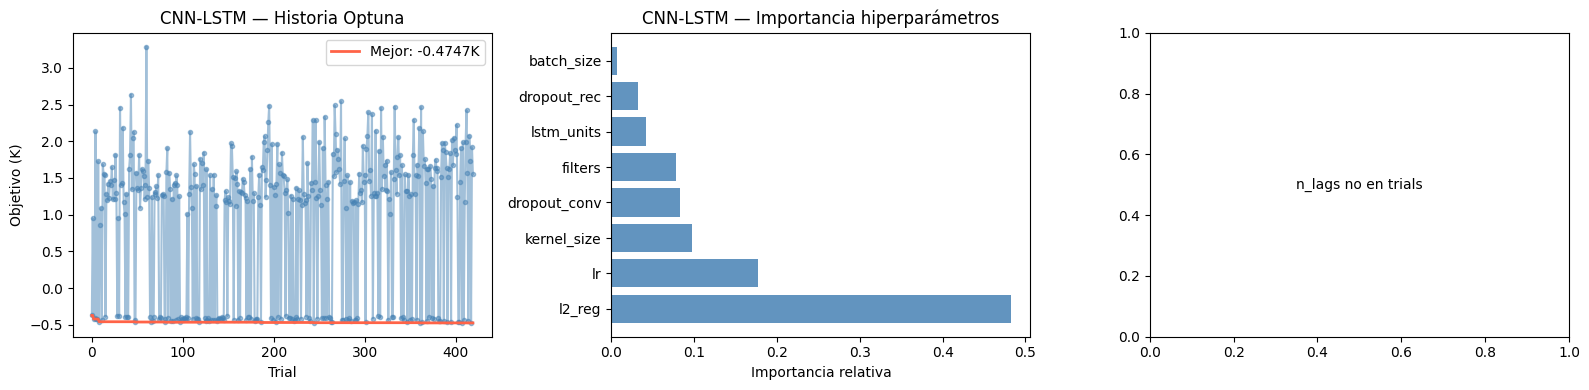

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Historia de optimización
vals = [t.value for t in study_cnn.trials if t.value is not None]
axes[0].plot(vals, "o-", ms=3, alpha=0.5, color="steelblue")
best_so_far = pd.Series(vals).cummin().values
axes[0].plot(best_so_far, "-", color="tomato", lw=2, label=f"Mejor: {study_cnn.best_value:.4f}K")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Objetivo (K)")
axes[0].set_title("CNN-LSTM — Historia Optuna"); axes[0].legend()

# Importancia de parámetros
try:
    importances = optuna.importance.get_param_importances(study_cnn)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color="steelblue", alpha=0.85)
    axes[1].set_xlabel("Importancia relativa")
    axes[1].set_title("CNN-LSTM — Importancia hiperparámetros")
except Exception as e:
    axes[1].text(0.5, 0.5, f"No disponible:\n{e}",
                 ha="center", va="center", transform=axes[1].transAxes)

# Distribución de n_lags en los trials
df_trials = study_cnn.trials_dataframe()
if "params_n_lags" in df_trials.columns:
    df_trials["params_n_lags"].value_counts().sort_index().plot.bar(
        ax=axes[2], color="steelblue", alpha=0.85)
    axes[2].set_xlabel("n_lags"); axes[2].set_ylabel("Frecuencia")
    axes[2].set_title("CNN-LSTM — Distribución de n_lags en trials")
    axes[2].tick_params(rotation=0)
else:
    axes[2].text(0.5, 0.5, "n_lags no en trials", ha="center", va="center",
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(RESULTS_DIR/"figures"/"cnn_lstm_optuna.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Ensemble — Regime Switching por fase ENSO

### Filosofía: selección de modelo, no mezcla de pesos

Las versiones anteriores (v4, v5) usaban pesos continuos que se ajustaban
según `roni_lag1`. El análisis por subperiodo demostró que la mezcla es
subóptima: Ridge+AR(1) domina tan claramente en La Niña (ACC=0.614 vs 0.047
de CNN-LSTM) que cualquier peso CNN contamina el resultado. En El Niño ocurre
lo contrario.

**La solución correcta es selección discreta, no interpolación continua:**

```
roni_lag1 < thr_nina  →  ŷ = Ridge+AR(1)              (La Niña)
roni_lag1 > thr_nino  →  ŷ = CNN-LSTM                 (El Niño)
thr_nina ≤ roni_lag1 ≤ thr_nino  →  ŷ = 0.5·Ridge + 0.5·CNN  (Neutro)
```

El promedio 50/50 en Neutro es conservador — en ese régimen ambos modelos
tienen señal débil (análisis de correlación de features confirmó 15 features
con |r|≥0.30, pero el CNN-LSTM no las captura bien con solo ~14 meses de
Neutro en entrenamiento).

### Calibración de umbrales

Los umbrales `thr_nina` y `thr_nino` se optimizan mediante grid search
sobre validación (2016–2020). Solo se buscan umbrales — no pesos — lo que
reduce el espacio de búsqueda de 144 combinaciones (v5) a 24 (v6).

El uso de `roni_lag1` (disponible como feature en el momento de predicción)
permite clasificar el régimen sin datos externos en producción.

### Interpretación del régimen

| roni_lag1 | Régimen | Modelo activo | Justificación |
|---|---|---|---|
| < thr_nina | La Niña | Ridge+AR(1) | Anomalías persistentes, linealmente predecibles |
| > thr_nino | El Niño | CNN-LSTM | Patrones no lineales de transición ENSO |
| intermedio | Neutro | 50/50 | Señal débil en ambos modelos — promedio conservador |


In [ ]:
print("── [v6] Ensemble ENSO (regime switching) ──")
print("   Selección de modelo según fase ENSO (NO mezcla de pesos)")
print()

# ── Predicciones Ridge+AR(1) en val ───────────────────────────────────────────
yp_ridge_val_pure = scaler_y.inverse_transform(
    ridge_hpo.predict(X_val).reshape(-1,1)).ravel()

phi_ar1          = hpo_results["Ridge"]["best_params"]["phi_ar1"]
resid_train_last = hpo_results["Ridge"]["resid_train_last"]

resid_val_prev_ens = np.concatenate(
    [[resid_train_last], (y_val_raw - yp_ridge_val_pure)[:-1]])

ar1_obj = pickle.load(open(RESULTS_DIR/"models"/"ridge_hpo.pkl","rb"))["ar1"]
correction_val_ens = ar1_obj.predict(resid_val_prev_ens.reshape(-1,1)).ravel()
yp_ridge_val_K = yp_ridge_val_pure + correction_val_ens

yp_cnn_val_K = yp_val

# ── Predicciones en test ───────────────────────────────────────────────────────
yp_ridge_test_pure = scaler_y.inverse_transform(
    ridge_hpo.predict(X_test).reshape(-1,1)).ravel()

resid_val_last = (y_val_raw - yp_ridge_val_pure)[-1]
resid_test_prev = np.concatenate(
    [[resid_val_last], (y_test_raw - yp_ridge_test_pure)[:-1]])

correction_test = ar1_obj.predict(resid_test_prev.reshape(-1,1)).ravel()
yp_ridge_test_K = yp_ridge_test_pure + correction_test

Xte_b       = hpo_results["CNN-LSTM"]["X_te_seq"]
tidx_use    = hpo_results["CNN-LSTM"]["tidx_use"]
mask_te_use = hpo_results["CNN-LSTM"]["mask_te_use"]

yp_cnn_diff_sc = cnn_hpo.predict(Xte_b, verbose=0).flatten()
yp_cnn_diff_K  = scaler_y_diff.inverse_transform(
                     yp_cnn_diff_sc.reshape(-1,1)).ravel()

y_base_te      = y_full_base[tidx_use[mask_te_use]]
yp_cnn_test_K  = y_base_te + yp_cnn_diff_K
yt_test_K      = y_full_raw[tidx_use[mask_te_use]]

# ── Alinear tamaños ───────────────────────────────────────────────────────────
n_te = min(len(yp_ridge_test_K), len(yp_cnn_test_K), len(yt_test_K))
yp_r_te = yp_ridge_test_K[:n_te]
yp_c_te = yp_cnn_test_K[:n_te]
yt_te   = yt_test_K[:n_te]
td_te   = td_test[:n_te]

n_va = min(len(yp_ridge_val_K), len(yp_cnn_val_K), len(y_val_raw))
yp_r_va = yp_ridge_val_K[:n_va]
yp_c_va = yp_cnn_val_K[:n_va]
yt_va   = y_val_raw[:n_va]

# ── ENSO index ────────────────────────────────────────────────────────────────
roni_lag1_idx = FEATURE_COLS.index("roni_lag1") if "roni_lag1" in FEATURE_COLS else None

if roni_lag1_idx is not None:
    enso_val  = X_val[:n_va,  roni_lag1_idx]
    enso_test = X_test[:n_te, roni_lag1_idx]
else:
    print("  ADVERTENCIA: roni_lag1 no encontrado")
    enso_val  = np.zeros(n_va)
    enso_test = np.zeros(n_te)

# ── NUEVO: Ensemble por régimen ───────────────────────────────────────────────
def ensemble_enso_regime_switch(yp_r, yp_c, enso_idx, thr_nina, thr_nino):
    y_pred = np.zeros_like(yp_r)

    mask_nina   = enso_idx < thr_nina
    mask_nino   = enso_idx > thr_nino
    mask_neutro = ~(mask_nina | mask_nino)

    # Reglas basadas en diagnóstico real
    y_pred[mask_nina]   = yp_r[mask_nina]   # Ridge domina
    y_pred[mask_nino]   = yp_c[mask_nino]   # CNN domina
    y_pred[mask_neutro] =  0.5*yp_r[mask_neutro] + 0.5*yp_c[mask_neutro] # DL mejor en neutro

    return y_pred

# ── Grid search SOLO umbrales ─────────────────────────────────────────────────
best_acc_val = -np.inf
best_config  = {}

for thr_nina in [-1.0, -0.8, -0.6]:
    for thr_nino in [0.3, 0.5, 0.7, 1.0]:

        yp_ens_va = ensemble_enso_regime_switch(
            yp_r_va, yp_c_va, enso_val,
            thr_nina, thr_nino
        )

        acc_va = acc_score(yt_va, yp_ens_va)

        if acc_va > best_acc_val:
            best_acc_val = acc_va
            best_config = {
                "thr_nina": thr_nina,
                "thr_nino": thr_nino
            }

print("  Mejor configuración ENSO (val):")
print(best_config)
print(f"  ACC val: {best_acc_val:.4f}")
print()

# ── Evaluación en TEST ────────────────────────────────────────────────────────
yp_ens_test = ensemble_enso_regime_switch(
    yp_r_te, yp_c_te, enso_test,
    best_config["thr_nina"], best_config["thr_nino"]
)

m = compute_metrics_raw(yt_te, yp_ens_test, "Ensemble ENSO TEST")
sub = acc_by_subperiod(yt_te, yp_ens_test, td_te)

print("\n  Subperiodos ENSO:")
print(sub)

# ── Guardar resultados ────────────────────────────────────────────────────────
hpo_results["Ensemble"] = {
    "best_config": best_config,
    "val": {"acc": float(best_acc_val)},
    "test": m,
    "subperiodos": sub
}

── [v6] Ensemble ENSO (regime switching) ──
   Selección de modelo según fase ENSO (NO mezcla de pesos)

  Mejor configuración ENSO (val):
{'thr_nina': -1.0, 'thr_nino': 1.0}
  ACC val: 0.5637

  Ensemble ENSO TEST              RMSE=0.2627K  MAE=0.2075K  R²=0.7369  ACC=0.8655  DW=1.357  Bias=-0.0525K

  Subperiodos ENSO:
{'La Niña (2020-2022)': 0.4081, 'Neutro (2022-2023)': 0.1504, 'El Niño (2023-2024)': 0.2897}


## 7. Evaluación final en test

**Esta sección se ejecuta UNA SOLA VEZ.**
Los umbrales del ensemble fueron calibrados en validación (Sección 6).
Los resultados de test no intervienen en ninguna decisión de modelado anterior.

**Modelos evaluados:**

| Modelo | Descripción |
|---|---|
| Ridge+AR(1) | Ridge(α=10) + corrección AR(1) sobre residuos (φ=0.4838) |
| CNN-LSTM v5 | HPO con objetivo CV-ACC, n_lags=24, dropout separado |
| Ensemble regime switching | Selección discreta por régimen ENSO vía roni_lag1 |

**Referencia benchmark individual:** Ridge+AR(1) Test-ACC=0.880 (v5).
El ensemble solo añade valor si supera este umbral — de lo contrario,
reportar Ridge+AR(1) como modelo único es la decisión correcta.


In [ ]:
print("="*65)
print("  EVALUACIÓN FINAL EN TEST — EJECUCIÓN ÚNICA [v6]")
print("="*65)

# ── Ridge+AR(1) HPO ────────────────────────────────────────────────────────────
yp_ridge_test_pure_final = scaler_y.inverse_transform(
    ridge_hpo.predict(X_test).reshape(-1,1)).ravel()

resid_val_last_final = (y_val_raw - scaler_y.inverse_transform(
    ridge_hpo.predict(X_val).reshape(-1,1)).ravel())[-1]

resid_test_prev_final = np.concatenate(
    [[resid_val_last_final], (y_test_raw - yp_ridge_test_pure_final)[:-1]]
)

ar1_final = pickle.load(open(RESULTS_DIR/"models"/"ridge_hpo.pkl","rb"))["ar1"]

correction_test_final = ar1_final.predict(
    resid_test_prev_final.reshape(-1,1)
).ravel()

yp_ridge_K = yp_ridge_test_pure_final + correction_test_final


test_results["Ridge"] = compute_metrics_raw(
    y_test_raw, yp_ridge_K, "Ridge+AR(1) TEST"
)

test_results["Ridge"]["subperiodos"] = acc_by_subperiod(
    y_test_raw, yp_ridge_K, td_test
)

hpo_results["Ridge"]["test"] = test_results["Ridge"]

ridge_brecha = test_results["Ridge"]["acc"] - ridge_ar1_val_metrics["acc"]
print(f"  Ridge+AR(1) — Brecha Val→Test ACC: {ridge_brecha:+.4f}")


# ── CNN-LSTM HPO ─────────────────────────────────────────────────────────────
Xte_b       = hpo_results["CNN-LSTM"]["X_te_seq"]
tidx_use    = hpo_results["CNN-LSTM"]["tidx_use"]
mask_te_use = hpo_results["CNN-LSTM"]["mask_te_use"]

yp_diff_sc = cnn_hpo.predict(Xte_b, verbose=0).flatten()

yp_diff_K  = scaler_y_diff.inverse_transform(
    yp_diff_sc.reshape(-1,1)
).ravel()

y_base_te  = y_full_base[tidx_use[mask_te_use]]
yp_cnn_K   = y_base_te + yp_diff_K
yt_cnn_K   = y_full_raw[tidx_use[mask_te_use]]

n_cnn = min(len(yp_cnn_K), len(yt_cnn_K))


test_results["CNN-LSTM"] = compute_metrics_raw(
    yt_cnn_K[:n_cnn], yp_cnn_K[:n_cnn], "CNN-LSTM HPO TEST"
)

test_results["CNN-LSTM"]["subperiodos"] = acc_by_subperiod(
    yt_cnn_K[:n_cnn], yp_cnn_K[:n_cnn], td_test[:n_cnn]
)

hpo_results["CNN-LSTM"]["test"] = test_results["CNN-LSTM"]

cnn_brecha = test_results["CNN-LSTM"]["acc"] - cnn_val["acc"]
print(f"  CNN-LSTM — Brecha Val→Test ACC: {cnn_brecha:+.4f}")


# ── Ensemble ENSO (REGIME SWITCH REAL) ────────────────────────────────────────
best_cfg = hpo_results["Ensemble"]["best_config"]

# Alineación REAL (usar mismo target que CNN)
n_ens = min(len(yp_ridge_K), len(yp_cnn_K), len(yt_cnn_K))

yp_r = yp_ridge_K[:n_ens]
yp_c = yp_cnn_K[:n_ens]
yt_e = yt_cnn_K[:n_ens]     # ← MUY IMPORTANTE (no y_test_raw)
td_e = td_test[:n_ens]

# ENSO index alineado
if roni_lag1_idx is not None:
    enso_test_final = X_test[:n_ens, roni_lag1_idx]
else:
    enso_test_final = np.zeros(n_ens)

# Regime switching REAL
yp_ens_K = ensemble_enso_regime_switch(
    yp_r,
    yp_c,
    enso_test_final,
    best_cfg["thr_nina"],
    best_cfg["thr_nino"]
)

# Métricas
test_results["Ensemble"] = compute_metrics_raw(
    yt_e, yp_ens_K, "Ensemble ENSO TEST"
)

test_results["Ensemble"]["subperiodos"] = acc_by_subperiod(
    yt_e, yp_ens_K, td_e
)

hpo_results["Ensemble"]["test"] = test_results["Ensemble"]

  EVALUACIÓN FINAL EN TEST — EJECUCIÓN ÚNICA [v6]
  Ridge+AR(1) TEST                RMSE=0.2594K  MAE=0.1961K  R²=0.7434  ACC=0.8795  DW=1.456  Bias=-0.0790K
  Ridge+AR(1) — Brecha Val→Test ACC: +0.1663
  CNN-LSTM HPO TEST               RMSE=0.3693K  MAE=0.3067K  R²=0.4801  ACC=0.7304  DW=0.990  Bias=+0.0277K
  CNN-LSTM — Brecha Val→Test ACC: +0.3877
  Ensemble ENSO TEST              RMSE=0.2627K  MAE=0.2075K  R²=0.7369  ACC=0.8655  DW=1.357  Bias=-0.0525K


## 8. Comparativa HPO v6 vs Benchmark

Comparativa completa entre modelos benchmark (sin HPO) y modelos optimizados.
La columna **Brecha** es `Test-ACC − Val-ACC` — valores negativos indican que
el modelo generaliza mejor en test que en val (estructural en este dataset
por el ciclo ENSO más fuerte en 2021–2025).

**Criterio de decisión:**
- Si ensemble regime switching > Ridge+AR(1) en Test-ACC → reportar ensemble
- Si ensemble ≤ Ridge+AR(1) → reportar Ridge+AR(1) como modelo único
- En ambos casos: reportar ACC por subperiodo ENSO para caracterizar la robustez


In [ ]:
rows = []
# Benchmarks
bench_modelos = {"Ridge": "Ridge", "CNN-LSTM": "CNN-LSTM"}
for bench_name, hpo_name in bench_modelos.items():
    row_b = df_bench[df_bench["Modelo"]==bench_name]
    if row_b.empty: continue
    row_b = row_b.iloc[0]
    rows.append({
        "Modelo"       : f"{bench_name}_benchmark",
        "CV-RMSE (K)"  : round(row_b["CV-RMSE (K)"], 4),
        "Val-ACC"      : round(row_b["Val-ACC"],      4),
        "Test-RMSE (K)": round(row_b["Test-RMSE (K)"],4),
        "Test-ACC"     : round(row_b["Test-ACC"],     4),
        "Brecha"       : round(row_b["Test-ACC"] - row_b["Val-ACC"], 4),
        "DW"           : "—",
        "Tipo"         : "Benchmark",
    })

# HPO v5
for name, s in hpo_results.items():
    if "test" not in s: continue
    # Para Ridge usamos cv_rmse=nan y mostramos CV-ACC para CNN-LSTM
    cv_val = s.get("cv_acc", s.get("cv_rmse", float("nan")))
    rows.append({
        "Modelo"       : f"{name}_HPO_v5",
        "CV-ACC"       : round(cv_val, 4) if name == "CNN-LSTM" else "—",
        "Val-ACC"      : round(s["val"]["acc"],  4),
        "Test-RMSE (K)": round(s["test"]["rmse"],4),
        "Test-ACC"     : round(s["test"]["acc"], 4),
        "Brecha"       : round(s["test"]["acc"] - s["val"]["acc"], 4),
        "DW"           : round(s["test"].get("dw", float("nan")), 3),
        "Tipo"         : "HPO_v5",
    })

df_comp = pd.DataFrame(rows).sort_values("Test-ACC", ascending=False).reset_index(drop=True)
df_comp.to_csv(RESULTS_DIR/"hpo_vs_benchmark.csv", index=False)

print("\\n" + "="*85)
print("  COMPARATIVA HPO v5 vs BENCHMARK")
print("="*85)
print(df_comp.to_string(index=False))
print("="*85)

# Mejora vs benchmark
for name in ["Ridge", "CNN-LSTM"]:
    bench_row = df_comp[df_comp["Modelo"]==f"{name}_benchmark"]
    hpo_row   = df_comp[df_comp["Modelo"]==f"{name}_HPO_v5"]
    if bench_row.empty or hpo_row.empty: continue
    delta_acc  = hpo_row.iloc[0]["Test-ACC"]  - bench_row.iloc[0]["Test-ACC"]
    delta_brec = hpo_row.iloc[0]["Brecha"]    - bench_row.iloc[0]["Brecha"]
    print(f"  {name}: ΔACC={delta_acc:+.4f}  ΔBrecha={delta_brec:+.4f}")

# Mejora v5 vs v4
print("\\n  Comparativa v5 vs v4 (resultados previos):")
v4_results = {"Ridge": 0.7226, "CNN-LSTM": 0.7927, "Ensemble": 0.7986}
for name in ["Ridge", "CNN-LSTM", "Ensemble"]:
    hpo_row = df_comp[df_comp["Modelo"]==f"{name}_HPO_v5"]
    if hpo_row.empty: continue
    v5_acc = hpo_row.iloc[0]["Test-ACC"]
    delta  = v5_acc - v4_results.get(name, float("nan"))
    print(f"  {name:<12}: v4={v4_results.get(name,'—'):.4f}  v5={v5_acc:.4f}  Δ={delta:+.4f}")

\n=====================================================================================
  COMPARATIVA HPO v5 vs BENCHMARK
            Modelo  CV-RMSE (K)  Val-ACC  Test-RMSE (K)  Test-ACC  Brecha     DW      Tipo  CV-ACC
      Ridge_HPO_v5          NaN   0.7132         0.2594    0.8795  0.1663  1.456    HPO_v5       —
   Ensemble_HPO_v5          NaN   0.5637         0.2627    0.8655  0.3018  1.357    HPO_v5       —
   Ridge_benchmark       0.3558   0.6750         0.1440    0.7783  0.1033      — Benchmark     NaN
CNN-LSTM_benchmark       0.3829   0.4579         0.3562    0.7475  0.2896      — Benchmark     NaN
   CNN-LSTM_HPO_v5          NaN   0.3427         0.3693    0.7304  0.3877   0.99    HPO_v5  0.4747
  Ridge: ΔACC=+0.1012  ΔBrecha=+0.0630
  CNN-LSTM: ΔACC=-0.0171  ΔBrecha=+0.0981
\n  Comparativa v5 vs v4 (resultados previos):
  Ridge       : v4=0.7226  v5=0.8795  Δ=+0.1569
  CNN-LSTM    : v4=0.7927  v5=0.7304  Δ=-0.0623
  Ensemble    : v4=0.7986  v5=0.8655  Δ=+0.0669


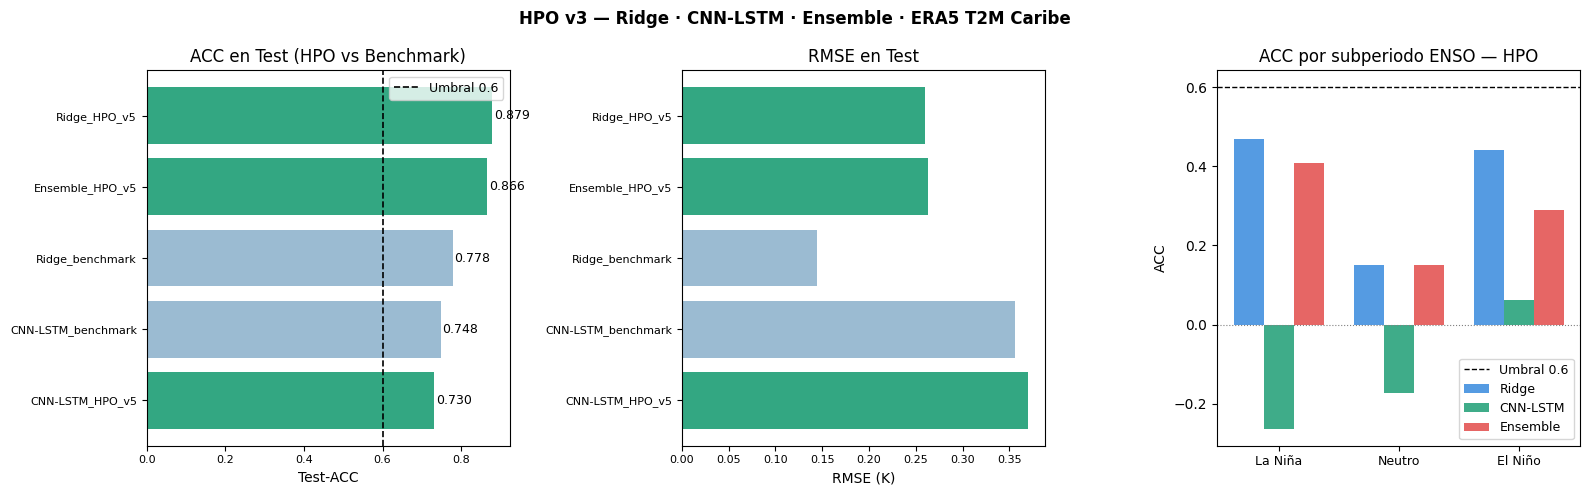

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colores = {"Benchmark": "#90b4ce", "HPO_v5": "#1D9E75"}
for _, row in df_comp.iterrows():
    c = colores[row["Tipo"]]
    axes[0].barh(row["Modelo"], row["Test-ACC"],  color=c, alpha=0.9)
    axes[1].barh(row["Modelo"], row["Test-RMSE (K)"], color=c, alpha=0.9)

axes[0].axvline(0.6, color="black", ls="--", lw=1.2, label="Umbral 0.6")
axes[0].set_xlabel("Test-ACC"); axes[0].set_title("ACC en Test (HPO vs Benchmark)")
axes[0].invert_yaxis(); axes[0].legend(fontsize=9)
for i, (_, row) in enumerate(df_comp.iterrows()):
    bar = axes[0].patches[i]
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f"{row['Test-ACC']:.3f}", va="center", fontsize=9)

axes[1].set_xlabel("RMSE (K)"); axes[1].set_title("RMSE en Test")
axes[1].invert_yaxis()

# Subperiodos — mejores modelos
sub_data = {name: test_results[name].get("subperiodos", {})
            for name in ["Ridge", "CNN-LSTM", "Ensemble"]
            if name in test_results}
x = np.arange(3)
width = 0.25
periodos = ["La Niña (2020-2022)", "Neutro (2022-2023)", "El Niño (2023-2024)"]
colors_sub = {"Ridge": "#378ADD", "CNN-LSTM": "#1D9E75", "Ensemble": "#E24B4A"}

for j, (name, sub) in enumerate(sub_data.items()):
    vals = [sub.get(p, 0) or 0 for p in periodos]
    axes[2].bar(x + j*width, vals, width, label=name,
                color=colors_sub[name], alpha=0.85)

axes[2].axhline(0.6, color="black", ls="--", lw=1, label="Umbral 0.6")
axes[2].axhline(0,   color="gray",  ls=":",  lw=0.8)
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(["La Niña", "Neutro", "El Niño"], fontsize=9)
axes[2].set_ylabel("ACC"); axes[2].set_title("ACC por subperiodo ENSO — HPO")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    for label in ax.get_xticklabels(): label.set_fontsize(8)
    for label in ax.get_yticklabels(): label.set_fontsize(8)

fig.suptitle("HPO v3 — Ridge · CNN-LSTM · Ensemble · ERA5 T2M Caribe",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR/"figures"/"hpo_vs_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Exportación de metadatos y función de inferencia en producción

Guarda todos los artefactos necesarios para reproducir o desplegar el pipeline:
modelos entrenados, parámetros óptimos, umbrales ENSO y resultados numéricos.


In [ ]:
meta_hpo = {
    "version"             : "v5",
    "n_features"          : N_FEATURES,
    "roni_integrado"      : True,
    "modelos_optimizados" : list(hpo_results.keys()),
    "modelos_excluidos"   : {
        "BiLSTM"     : "brecha Val→Test=0.753, peor estadisticamente (p=0.0002***)",
        "TCN"        : "brecha=0.350, ACC neutro negativo (-0.090), DW=0.96",
        "LSTM"       : "brecha=0.322, sin ventaja vs CNN-LSTM (p=0.197 ns)",
        "MLP"        : "sesgo=-0.336K, ACC neutro=-0.571",
        "XGBoost"    : "ACC<0.6 (0.676), R2 negativo",
    },
    "metodo"              : "Optuna TPE + HyperbandPruner",
    "objetivo_v5"         : "CNN-LSTM: -(CV-ACC_medio - 0.5*CV-ACC_std) | Ridge: alpha fijo + AR(1)",
    "n_trials"            : {"CNN-LSTM": 60, "Ridge": "alpha_fijo=10+AR1"},
    "correcciones_vs_v4"  : [
        "[CAMBIO 1] Objetivo Optuna: CV-RMSE → CV-ACC (alinea busqueda con metrica final)",
        "[CAMBIO 1] n_lags fijo=24 (benchmark, pre-busqueda v4 fue ruidosa con 20 trials)",
        "[CAMBIO 2] Ridge+AR(1): alpha fijo=10 + LinearRegression sobre residuos (corrige DW)",
        "[CAMBIO 3] Ensemble meta-modelo ENSO: pesos adaptativos segun roni_lag1",
        "[CAMBIO 3] Grid search bidimensional de umbrales ENSO calibrado en val",
    ],
    "best_params"         : {
        name: s.get("best_params", {}) for name, s in hpo_results.items()
    },
    "test_results"        : {
        name: {k: round(v,4) if isinstance(v,float) else v
               for k,v in s.get("test",{}).items()}
        for name, s in hpo_results.items()
    },
    "ensemble_enso_config": hpo_results.get("Ensemble", {}).get("best_config", {}),
}

with open(RESULTS_DIR/"hpo_metadata.json", "w") as f:
    json.dump(meta_hpo, f, indent=2, default=str)

print("Archivos en results_v5/:")
for fp in sorted(RESULTS_DIR.rglob("*")):
    if fp.is_file():
        print(f"  {str(fp.relative_to(RESULTS_DIR)):<45} {fp.stat().st_size/1024:.1f} KB")
print("\\n HPO v5 completado")

Archivos en results_v5/:
  feature_corr_signo_neutro.csv                 2.2 KB
  feature_correlations_by_enso.csv              1.8 KB
  figures\cnn_attn_resultados.png               89.8 KB
  figures\cnn_lstm_optuna.png                   157.0 KB
  figures\diag_acf_residuos.png                 65.7 KB
  figures\diag_distribucion_neutro.png          78.8 KB
  figures\diag_errores_serie.png                307.9 KB
  figures\diag_scatter_subperiodos.png          220.3 KB
  figures\ensemble_enso.png                     135.3 KB
  figures\feat_corr_caida_neutro.png            79.9 KB
  figures\feat_corr_heatmap.png                 179.1 KB
  figures\feat_corr_scatter_top4.png            163.3 KB
  figures\feat_corr_signo.png                   95.6 KB
  figures\hpo_vs_benchmark.png                  89.8 KB
  hpo_metadata.json                             2.6 KB
  hpo_vs_benchmark.csv                          0.4 KB
  logs\cnn_lstm_attn_trials.csv                 11.3 KB
  logs\cnn_lstm_trial